# Finding Donors for CharityML
## Introdução

Aqui está a tradução do texto para o português, mantendo a formatação e os links originais:

## Primeiros Passos

Neste projeto, você empregará vários algoritmos supervisionados de sua escolha para modelar com precisão a renda de indivíduos usando dados coletados do Censo dos EUA de 1994. Você então escolherá o melhor algoritmo candidato a partir de resultados preliminares e otimizará ainda mais este algoritmo para modelar os dados da melhor forma. Seu objetivo com esta implementação é construir um modelo que preveja com precisão se um indivíduo ganha mais de US$ 50.000. Esse tipo de tarefa pode surgir em um ambiente sem fins lucrativos, onde as organizações sobrevivem de doações. Compreender a renda de um indivíduo pode ajudar uma instituição sem fins lucrativos a entender melhor qual o tamanho da doação a ser solicitada, ou se sequer devem entrar em contato. Embora possa ser difícil determinar a faixa de renda geral de um indivíduo diretamente de fontes públicas, podemos (como veremos) inferir esse valor a partir de outras características (*features*) publicamente disponíveis.

O conjunto de dados para este projeto é originário do [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income). O conjunto de dados foi doado por Ron Kohavi e Barry Becker, após ser publicado no artigo _"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"_. Você pode encontrar o artigo de Ron Kohavi [online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf). Os dados que investigamos aqui consistem em pequenas alterações no conjunto de dados original, como a remoção da *feature* `fnlwgt` e de registros com entradas ausentes ou mal formatadas.


Premissas já conhecidas do contexto:
- O problema é de classificação binária supervisionada.
- O alvo é prever se uma pessoa possui renda `>50K`.
- O uso pretendido é apoiar a priorização de contatos da CharityML.
- A métrica de negócio mais coerente continua sendo `F-beta` com `beta = 0.5`, pois falsos positivos representam cartas enviadas sem retorno esperado.


# 1. Business Understanding

## 1.1 Contexto de negócio
A CharityML precisa decidir para quais pessoas vale a pena direcionar campanhas de arrecadação. Como o custo de contato não é nulo, o objetivo não é apenas encontrar o maior número possível de potenciais doadores, mas principalmente evitar desperdício de esforço com perfis pouco promissores.

Neste projeto, a renda anual acima de `50 mil dólares` é usada como proxy para maior capacidade de doação. Portanto, o modelo não está prevendo doação diretamente: ele estima a chance de o indivíduo pertencer a uma faixa de renda que, em tese, torna uma doação mais provável ou mais valiosa.

## 1.2 Problema analítico
Traduzindo o problema de negócio para análise de dados:

**Queremos classificar indivíduos entre `<=50K` e `>50K` para apoiar uma estratégia de priorização de outreach, maximizando precisão sem perder completamente cobertura.**
___

**Estratégia de priorização de outreach** é o processo de *classificar* e ordenar potenciais doadores (ou clientes), por *probabilidade de conversão*, para direcionar os esforços de contato (ligações, e-mails, visitas) primeiro para quem tem maior chance de doar.

* Em vez de contatar todas as pessoas do censo aleatoriamente, treinamos um modelo para prever quem ganha >50K (*proxy para capacidade de doação*)
* O modelo gera uma pontuação/probabilidade para cada pessoa
* A ONG então contata primeiro os mais prováveis, otimizando tempo e recursos.
  
```mermaid
flowchart TD
    A["📊 Dados do Censo"] --> B["🤖 Modelo de Classificação"]
    B --> C["📈 Score de Probabilidade\n(renda >50K)"]
    C --> D["🔽 Ranking Descendente\npor Score"]
    D --> E{"Definir Corte\n(ex: top 20%)"}
    E -->|Alta prioridade| F["🎯 Grupo Prioritário\nde Outreach"]
    E -->|Baixa prioridade| G["⏸️ Grupo Secundário\n(contato posterior)"]
    F --> H["📞 Equipe de Outreach\ncontata primeiro"]
    H --> I["💰 Maior taxa de\nconversão de doações"]

    style A fill:#4a90d9,stroke:#333,color:#fff
    style B fill:#7b68ee,stroke:#333,color:#fff
    style C fill:#f39c12,stroke:#333,color:#fff
    style D fill:#e67e22,stroke:#333,color:#fff
    style E fill:#e74c3c,stroke:#333,color:#fff
    style F fill:#27ae60,stroke:#333,color:#fff
    style G fill:#95a5a6,stroke:#333,color:#fff
    style H fill:#2ecc71,stroke:#333,color:#fff
    style I fill:#1abc9c,stroke:#333,color:#fff
```
___

## 1.3 Decisão que o modelo precisa apoiar
A saída do modelo deve apoiar uma decisão operacional simples:
- quem entra primeiro na lista de abordagem da CharityML;
- quais perfis devem receber campanhas mais custosas;
- onde vale testar cortes de score para balancear volume de contatos e eficiência.

## 1.4 Stakeholders principais
- Time de captação de recursos: quer listas com maior probabilidade de retorno.
- Liderança da organização: quer reduzir desperdício operacional.
- Time analítico: precisa de um pipeline reproduzível, interpretável e auditável.

---

## 🎯 Matriz de Confusão e Métricas para a Classe Positiva

> **Definição de classes no projeto:**
> - **Positivo (+)** → renda **>50K** → potencial doador ✅
> - **Negativo (−)** → renda **≤50K** → não doador ❌

---

### 📊 Matriz de Confusão

|  | **Previsto: >50K** | **Previsto: ≤50K** |
|:---|:---:|:---:|
| **Real: >50K** | ✅ **VP** — Verdadeiro Positivo | ❌ **FN** — Falso Negativo |
| **Real: ≤50K** | ⚠️ **FP** — Falso Positivo | ✅ **VN** — Verdadeiro Negativo |

#### Interpretação no contexto do projeto:

| Célula | O que significa | Impacto |
|:---|:---|:---|
| **VP** | Previu >50K e é doador real | Contato certeiro — conversão garantida |
| **FN** | Previu ≤50K mas era doador real | **Doador perdido** — oportunidade de receita perdida |
| **FP** | Previu >50K mas não é doador | Esforço de outreach desperdiçado — custo sem retorno |
| **VN** | Previu ≤50K e não é doador | Descarte correto — eficiência operacional |

---

### 📐 Métricas que favorecem a Classe Positiva

#### 1. Precision (Precisão)
> *"Dos que eu previ como doadores, quantos realmente são?"*

$$\text{Precision} = \frac{VP}{VP + FP}$$

- Alta Precision → poucos FP → **menos contatos desnecessários**
- Útil quando o **custo de outreach é alto**

---

#### 2. Recall (Sensibilidade / Revocação)
> *"De todos os doadores reais, quantos eu consegui identificar?"*

$$\text{Recall} = \frac{VP}{VP + FN}$$

- Alto Recall → poucos FN → **menos doadores perdidos**
- Útil quando **perder um doador é muito custoso**

---

#### 3. F1-Score
> *"Equilíbrio entre Precision e Recall"*

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

- Métrica única que **balanceia os dois erros**
- Indicada quando as duas classes têm peso similar

---

#### 4. F-beta Score ⭐ (mais relevante para este projeto)
> *"Equilíbrio ponderado — controla o quanto Recall importa mais que Precision"*

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{(\beta^2 \times \text{Precision}) + \text{Recall}}$$

| Valor de β | Interpretação |
|:---:|:---|
| β < 1 | Precision tem mais peso |
| β = 1 | F1 — peso igual |
| **β > 1** | **Recall tem mais peso → prioriza não perder doadores** |

> **No CharityML, usamos β = 0.5** → damos mais peso à Precision, pois o custo de contatar não-doadores (FP) também importa para a eficiência da ONG.

---

### 🧭 Resumo Visual: O que cada erro custa

```
                    ┌──────────────────────────────────────┐
                    │         ERRO TIPO I (FP)             │
                    │   Contactamos quem não vai doar       │
                    │   → Custo: tempo e dinheiro perdidos  │
                    └──────────────────────────────────────┘
                                      ▲
                    Precision protege contra esse erro

                    ┌──────────────────────────────────────┐
                    │         ERRO TIPO II (FN)            │
                    │   Ignoramos quem ia doar              │
                    │   → Custo: receita perdida para ONG  │
                    └──────────────────────────────────────┘
                                      ▲
                    Recall protege contra esse erro
```

> **Conclusão:** A escolha da métrica depende do **custo relativo** de cada tipo de erro. No contexto de doações, ambos importam — por isso o **F-beta com β calibrado** é a métrica de escolha.

---


## Dicionário e Classificação Semântica das Variáveis

### Por que este dicionário pertence ao *Business Understanding*

No contexto do CRISP-DM, a etapa de *Business Understanding* não se limita à definição do problema de negócio. Ela também inclui o entendimento inicial sobre o significado das variáveis disponíveis, antes mesmo da análise exploratória detalhada. Um dicionário semântico nesta fase ajuda a:

- ancorar as hipóteses em semântica real, e não apenas em nomes de colunas;
- orientar a EDA com perguntas mais relevantes, evitando análise descritiva sem propósito;
- documentar previamente decisões de uso, como variáveis sensíveis, proxies e possíveis redundâncias.

Esse cuidado é especialmente importante neste projeto, pois algumas variáveis têm interpretação ambígua ou sobreposta, como `education_level` e `education-num`, e outras exigem atenção ética e analítica, como `sex`, `race` e `native-country`.

### Classificação Semântica das Variáveis

| Grupo | Variáveis | Natureza | Interpretação analítica |
|---|---|---|---|
| Perfil demográfico | `age`, `sex`, `race`, `native-country` | Estrutural / sensível | Características individuais de base. Podem explicar padrões de renda, mas exigem cuidado por envolverem atributos sensíveis ou potencialmente discriminatórios. |
| Capital humano | `education_level`, `education-num` | Ordinal / redundante entre si | Representam escolaridade sob duas formas: categórica e ordinal numérica. Tendem a capturar qualificação e potencial de renda futura. |
| Situação ocupacional | `workclass`, `occupation`, `hours-per-week` | Comportamental / econômica | Descrevem inserção no mercado de trabalho e intensidade de trabalho. Devem ter relação direta com capacidade de geração de renda. |
| Estrutura familiar | `marital-status`, `relationship` | Proxy de composição domiciliar | Variáveis ligadas ao arranjo familiar e posição no domicílio. Podem refletir estabilidade econômica, responsabilidades e contexto social. |
| Eventos financeiros | `capital-gain`, `capital-loss` | Esparso / alto sinal quando diferente de zero | Capturam eventos financeiros não recorrentes. Apesar de esparsas, podem ter forte associação com faixas de renda mais altas. |
| Censo | `fnlwgt` | Peso amostral | Peso estatístico da amostra no levantamento censitário. Em geral, não é tratado como *feature* preditiva principal. |
| Target | `income` | Binário | Variável alvo do problema: `>50K` ou `<=50K`. Indica se o indivíduo é classificado como potencial doador ou não. |

### Observações importantes sobre algumas variáveis

| Variável | Observação |
|---|---|
| `education_level` | Escolaridade em formato categórico nominal/ordinal interpretável. |
| `education-num` | Representação numérica ordinal da escolaridade; potencialmente redundante com `education_level`. |
| `fnlwgt` | Peso amostral do censo; útil em análise estatística, mas nem sempre apropriado para modelagem preditiva direta. |
| `sex`, `race`, `native-country` | Variáveis sensíveis; podem ser úteis para diagnóstico de viés, mas exigem cuidado ético no uso preditivo. |
| `capital-gain`, `capital-loss` | Variáveis geralmente concentradas em zero, mas com alto poder explicativo quando assumem valores positivos. |

### Relação entre os grupos e as hipóteses analíticas

Esse agrupamento semântico também torna as hipóteses mais rastreáveis ao problema:

- H1 e H2 se conectam principalmente a capital humano e situação ocupacional.
- H3 se relaciona à situação ocupacional e ao ciclo de vida, com destaque para `age` e `hours-per-week`.
- H4 se apoia na estrutura familiar.
- H5 depende dos eventos financeiros.
- H6 se relaciona ao perfil demográfico, grupo que requer maior atenção por incluir atributos sensíveis.

### Implicação para a análise

Antes da modelagem, este dicionário ajuda a separar:

- variáveis com sinal econômico direto;
- variáveis com possível redundância;
- variáveis com papel mais contextual que preditivo;
- variáveis sensíveis, que devem ser analisadas com cautela.

## 1.5 Critério de sucesso de negócio
O projeto será considerado útil se entregar um modelo que:
- supere claramente um baseline ingênuo;
- tenha boa precisão na classe positiva;
- permita explicar por que certos perfis tendem a ser priorizados;
- possa ser calibrado conforme o orçamento de campanha.

## 1.6 Critério de sucesso analítico
Como o custo de contatar falsos positivos é relevante, a métrica principal recomendada é `F0.5`, que dá mais peso à precisão do que ao recall. Métricas auxiliares:
- precisão;
- recall;
- acurácia apenas como apoio contextual;
- matriz de confusão para discutir trade-offs.

## 1.7 Riscos e cuidados
- Renda alta nao equivale automaticamente a propensão de doação.
- Variáveis demográficas podem aumentar performance e, ao mesmo tempo, trazer risco de vieses indesejados.
- Uma análise com muitos gráficos desconectados do problema tende a consumir tempo e não melhora decisão.
- Algumas variáveis podem ser redundantes ou altamente assimétricas, exigindo tratamento cuidadoso antes da modelagem.

## 1.8 Hipóteses analíticas iniciais

As hipóteses abaixo foram definidas para guiar a análise e evitar EDA genérica. 

"Acredito que a *feature ou grupo de features* tenha uma relação com o alvo, porque *racional de negócio*. Vou investigar isso *comparando evidências ou cortes analíticos*. "

Exemplo: 
"Acredito que clientes com maior tempo de relacionamento tenham maior chance de renovacao, porque relacoes mais longas indicam maior fidelizacao. Vou investigar isso comparando a > taxa de renovacao por faixa de tempo de casa."

#### Hipótese H1
**Maior escolaridade está associada a maior probabilidade de renda `>50K`.**

Racional:
- escolaridade costuma se relacionar com acesso a ocupações mais qualificadas e melhor remuneração;
- no dataset, `education-num` representa uma versão ordinal da escolaridade e deve ser comparada com `education_level` para avaliar redundância e força preditiva.

#### Hipótese H2
**Indivíduos em ocupações de maior senioridade ou especialização tendem a concentrar a classe positiva.**

Racional:
- cargos como `Exec-managerial` e `Prof-specialty` devem apresentar taxas de `>50K` superiores à média;
- categorias ocupacionais com baixa remuneração relativa devem concentrar a classe `<=50K`.

#### Hipótese H3
**Carga de trabalho e estágio de carreira importam: idade e horas semanais possuem relação não linear com renda.**

Racional:
- perfis muito jovens tendem a ter menor renda por início de carreira;
- faixas intermediárias de idade podem concentrar pico de renda;
- trabalhar mais horas pode estar associado a ocupações e arranjos profissionais de maior remuneração, mas não de forma uniforme.

#### Hipótese H4
**Variáveis ligadas à estrutura familiar e conjugal ajudam a separar grupos com diferentes padrões de renda.**

Racional:
- `marital-status` e `relationship` podem capturar estabilidade familiar, composição domiciliar e dinâmica econômica do indivíduo;
- espera-se maior incidência de `>50K` em grupos como `Married-civ-spouse` em comparação com perfis `Never-married`.

#### Hipótese H5
**Eventos financeiros raros, como `capital-gain > 0`, têm alto poder discriminativo, mesmo aparecendo em poucos registros.**

Racional:
- o dataset costuma concentrar muitos zeros em `capital-gain` e `capital-loss`;
- quando há valor positivo, o sinal para alta renda tende a ser muito forte, mas assimétrico.

#### Hipótese H6
**Nem toda variável com poder preditivo deve ser automaticamente priorizada para decisão.**

Racional:
- `sex`, `race` e `native-country` podem aparecer como relevantes para o modelo, mas precisam ser analisadas com cautela sob a ótica de justiça, risco reputacional e uso responsável.
- aqui o objetivo é diferenciar “variável útil para previsão” de “variável apropriada para orientar decisão de negócio”.


```mermaid
mindmap
  root((Criacao de hipoteses analiticas))
    Negocio
      Problema real
      Decisao a apoiar
      Custo do erro
      Criterio de sucesso
    Traducao analitica
      Pergunta central
      Definicao do alvo
      O que precisa ser explicado
    Mecanismos plausiveis
      Escolaridade
      Ocupacao
      Idade
      Horas trabalhadas
      Capital gain
      Estrutura familiar
      Variaveis sensiveis
    Hipoteses
      H1 Escolaridade aumenta chance de >50K
      H2 Ocupacoes especializadas concentram >50K
      H3 Idade e horas tem relacao nao linear
      H4 Estado civil e relacao ajudam a separar grupos
      H5 Capital gain > 0 tem sinal forte
      H6 Nem toda feature preditiva deve virar regra de negocio
    Teste
      Comparar sempre com target
      Tabelas de taxa positiva
      Medianas e quantis
      Volumes por categoria
      Redundancia entre variaveis
    Resultado
      Insights acionaveis
      Decisoes de preparacao
      Escolha de modelos
      Interpretacao responsavel
```

## Mapa Mental das Hipóteses

```mermaid
graph TD
    classDef problemNode fill:#2d6a4f,color:#fff,stroke:#1b4332,rx:8
    classDef hypothesisNode fill:#1d3557,color:#fff,stroke:#457b9d,rx:6
    classDef contrarianNode fill:#6d2b3d,color:#fff,stroke:#c9184a,stroke-dasharray:6 3,rx:6
    classDef testNode fill:#f4a261,color:#000,stroke:#e76f51,rx:4
    classDef confirmedNode fill:#2a9d8f,color:#fff,stroke:#264653,rx:6
    classDef refutedNode fill:#e63946,color:#fff,stroke:#c1121f,rx:6

    PROBLEM["🎯 CharityML — Donor Targeting\nPredict individuals with income > 50K\nTarget: income (binary: <=50K / >50K)"]:::problemNode

    H1["H1 — Education Level\neducation / education-num → Higher ed = higher income\nStatus: Pendente"]:::hypothesisNode
    H2["H2 — Occupation Type\noccupation → Exec/Prof roles = higher income\nStatus: Pendente"]:::hypothesisNode
    H3["H3 — Capital Assets\ncapital-gain / capital-loss → Wealth signal\nStatus: Pendente"]:::hypothesisNode
    H4["⚡ H4 — Hours Worked\nhours-per-week → More hours = higher income\nStatus: Pendente"]:::contrarianNode
    H5["H5 — Age / Career Stage\nage → Mid-career peak 35-55\nStatus: Pendente"]:::hypothesisNode
    H6["H6 — Marital and Household Role\nmarital-status / relationship → Household head = higher income\nStatus: Pendente"]:::hypothesisNode

    TEST_H1["🔬 Positive-class rate\nacross education levels"]:::testNode
    TEST_H2["🔬 Rank occupation categories\nby positive-class rate"]:::testNode
    TEST_H3["🔬 Distribution comparison\ncapital features by income class"]:::testNode
    TEST_H4["🔬 Mean hours-per-week\nacross income classes"]:::testNode
    TEST_H5["🔬 Positive-class rate\nacross age bins"]:::testNode
    TEST_H6["🔬 Positive-class rate\nacross marital-status and relationship"]:::testNode

    PROBLEM --> H1
    PROBLEM --> H2
    PROBLEM --> H3
    PROBLEM --> H4
    PROBLEM --> H5
    PROBLEM --> H6

    H1 --> TEST_H1
    H2 --> TEST_H2
    H3 --> TEST_H3
    H4 --> TEST_H4
    H5 --> TEST_H5
    H6 --> TEST_H6
```

## Hipóteses — Referência Rápida

| # | Nome Curto | Variável | Direção Esperada | Método de Teste | Status |
|---|---|---|---|---|---|
| H1 | Education Level | `education` / `education-num` | Higher education → higher P(income >50K) | Positive-class rate across education levels | Pendente |
| H2 | Occupation Type | `occupation` | Exec/Prof/Specialty roles → higher income | Rank occupation categories by positive-class rate | Pendente |
| H3 | Capital Assets | `capital-gain` / `capital-loss` | Non-zero capital activity → higher income | Distribution comparison by income class | Pendente |
| H4 ⚡ | Hours Worked | `hours-per-week` | More hours → higher income (may not hold for salaried) | Mean hours-per-week across income classes | Pendente |
| H5 | Age / Career Stage | `age` | Mid-career (35–55) → peak income probability | Positive-class rate across age bins | Pendente |
| H6 | Marital & Household Role | `marital-status` / `relationship` | Married household head → higher income | Positive-class rate across marital-status and relationship | Pendente |

## Legenda

| Cor do nó | Significado |
|---|---|
| Verde escuro | Problem Statement |
| Azul escuro | Hipótese pendente |
| Vermelho bordô (tracejado) | Hipótese contrarian |
| Verde água | Hipótese confirmada |
| Vermelho | Hipótese refutada |
| Laranja | Método de teste |

### Regra final para levar para qualquer projeto

Se voce quiser uma regra curta para memorizar, use esta:

> **Hipotese boa conecta negocio, mecanismo plausivel, dado disponivel e decisao analitica.**

Quando essa conexao aparece, a exploracao deixa de ser barulho e passa a produzir direcao.

## 1.9 Evidências rápidas já observadas no dataset

Alguns sinais preliminares ajudam a priorizar a próxima etapa:
- Base com `45.222` registros.
- Classe positiva (`>50K`) com `11.208` registros, cerca de `24,8%` da base.
- Não foram encontrados valores faltantes aparentes no arquivo fornecido.
- Faixas de maior escolaridade apresentam taxa positiva muito superior às faixas mais baixas.
- Registros com `capital-gain > 0` concentram taxa positiva muito acima da média.
- Jornadas acima de `45h/semana` e idades intermediárias parecem mais associadas à classe positiva.

Esses sinais não encerram a análise; eles apenas justificam por que algumas variáveis devem ser examinadas antes de outras.


## 1.10 Roteiro recomendado para a etapa de Data Understanding

A etapa de Data Understanding deve responder perguntas de negócio, não “esgotar” o dataset visualmente. O roteiro abaixo foi desenhado para evitar gráficos decorativos.

### Perguntas que realmente importam nesta fase
1. O target está balanceado o suficiente para exigir atenção especial nas métricas e na estratégia de modelagem?
2. Quais variáveis parecem realmente separar a classe `>50K` da classe `<=50K`?
3. Existem sinais de assimetria, redundância, caudas longas ou categorias raras que afetem preparação e modelagem?
4. Há variáveis sensíveis cujo uso precisa de cuidado adicional na interpretação?

### Ordem sugerida da análise
1. **Sanidade estrutural**
   - shape, tipos, valores faltantes, duplicados, cardinalidade e distribuição do target.
   - Sem gráficos, exceto se algum problema estrutural exigir destaque.

2. **Análise orientada ao target**
   - comparar taxa de `>50K` por variável, e não apenas distribuição bruta da variável;
   - priorizar `education-num`, `education_level`, `occupation`, `marital-status`, `relationship`, `age`, `hours-per-week`, `capital-gain` e `capital-loss`.

3. **Numéricas com foco em decisão**
   - usar tabelas-resumo por classe, medianas e quantis;
   - visualizar somente as variáveis em que a comparação entre classes sugira mudança de tratamento, por exemplo log-transformação em `capital-gain` e `capital-loss`.

4. **Categóricas com foco em taxa positiva e volume**
   - calcular `count`, `count_pos` e `taxa_>50K` por categoria;
   - ordenar por taxa e por volume para separar efeito real de categoria rara.

5. **Redundância e risco de vazamento semântico**
   - verificar a sobreposição entre `education_level` e `education-num`;
   - revisar o quanto `relationship` e `marital-status` contam histórias parecidas;
   - documentar a decisão de manter, transformar ou apenas monitorar essas colunas.

6. **Fechamento da etapa**
   - cada insight deve terminar com uma implicação prática para a preparação ou modelagem.
   - exemplos: transformar, agrupar categorias raras, manter variável, monitorar viés, testar modelo mais interpretável.

### O que evitar explicitamente
- histogramas para todas as colunas sem ligação com hipóteses;
- gráficos de contagem sem comparação com o target;
- pairplot completo do dataset;
- mapas de calor com dezenas de variáveis dummificadas sem pergunta analítica definida;
- repetir o mesmo insight em vários tipos de gráfico.

### Regra prática de qualidade
**Um gráfico só entra no notebook se mudar uma decisão.**
Se ele não altera preparo, modelagem, métrica, interpretação ou risco, ele provavelmente deve ficar fora.


In [1]:
# Configuração inicial do estudo
from IPython.display import display
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid", palette="Blues")

DATA_PATH = Path("/home/fabiolima/Desktop/Finding_Donors_Project/data/census.csv")

df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())


(45222, 14)


,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


# 2. Data Understanding

## Objetivo desta etapa
Confirmar a qualidade e a estrutura da base, validar as hipóteses priorizadas no Business Understanding e registrar apenas os achados que impactam preparação, modelagem ou interpretação.

## Entregáveis esperados
- diagnóstico estrutural da base;
- leitura objetiva da distribuição do target;
- comparação entre classes para variáveis prioritárias;
- lista de decisões para a etapa de preparação.


In [2]:
# 2.1 Sanidade estrutural da base

print("Shape:", df.shape)
print()
print("Tipos:")
display(df.dtypes.to_frame("dtype"))

print()
print("Valores faltantes por coluna:")
display(df.isna().sum().to_frame("missing"))

print()
print("Duplicados:")
print(df.duplicated().sum())

print()
print("Cardinalidade das categóricas:")
cat_cols = df.select_dtypes(include=["object", "str", "category"]).columns.tolist()
card = pd.Series({col: df[col].nunique() for col in cat_cols}).sort_values(
    ascending=False
)
display(card.to_frame("n_unique"))


Shape: (45222, 14)

Tipos:


,dtype
age,int64
workclass,str
education_level,str
education-num,float64
marital-status,str
occupation,str
relationship,str
race,str
sex,str
capital-gain,float64



Valores faltantes por coluna:


,missing
age,0
workclass,0
education_level,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0



Duplicados:
5982

Cardinalidade das categóricas:


,n_unique
native-country,41
education_level,16
occupation,14
workclass,7
marital-status,7
relationship,6
race,5
sex,2
income,2


In [3]:
# 2.2 Leitura do target e baseline operacional

target_col = "income"
positive_label = ">50K"

target_summary = (
    df[target_col].value_counts().rename_axis("classe").reset_index(name="qtd")
)
target_summary["percentual"] = target_summary["qtd"] / target_summary["qtd"].sum()
display(target_summary)

base_rate = (df[target_col] == positive_label).mean()
print(f"Taxa da classe positiva: {base_rate:.2%}")


,classe,qtd,percentual
0,<=50K,34014,0.752156
1,>50K,11208,0.247844


Taxa da classe positiva: 24.78%


## Análise exploratória dirigida por hipóteses:

Depois da sanidade estrutural da base, a análise deixa de perguntar apenas "como são os dados?" e passa a perguntar "quais variáveis realmente ajudam a separar a classe `>50K` da classe `<=50K?`"

### Grupo Semântico 1: Capital Humano

#### Hipótese 1 -- Escolaridade e Renda
A escolaridade separa as duas classes ?

`P(income > 50 | education = X) = ?`

Para cada nível educacional X, qual é a fração de pessoas com renda acima de 50K?
* taxa da classe positiva por categoria (*positive class rate*)
* na base inteira qual é a taxa de `>50K`?
* 
$P(\text{income} > 50K) = \frac{\text{total de casos } > 50K}{\text{total de registros}}$

Essa é a *taxa marginal* -  o que um modelo ingênuo acertaria chutando sempre a classe majoritária. Quando analisar cada categoria de escolaridade, a pergunta é:
    * *Essa categoria está acima ou abaixo da taxa marginal?*

Categorias muito acima da baseline são fortes sinais de separação. Categorias muito abaixo também. Categorias próximas da baseline não adicionam informação.

O que torna uma variável discriminativa?

Uma variável é útil para o modelo quando a taxa da classe positiva varia significativamente entre as categorias. Se todos os níveis de educação tivessem a mesma taxa de `>50K`, a variável seria irrelevante — sabendo o nível educacional, você não aprenderia nada sobre a classe.

O que você busca visualmente: uma curva com bastante variação vertical entre as categorias, com algumas claramente acima e outras claramente abaixo da baseline.


1. calcular a taxa marginal (baseline)
2. agrupar por education → calcular positive class rate por categoria
3. ordenar as categorias por taxa decrescente
4. visualizar com a baseline como referência
5. interpretar — a hipótese se confirma?

### Grupo Semântico 1: Capital Humano

#### Hipótese H1 — Escolaridade está associada à renda acima de 50K

A hipótese central deste grupo é que níveis mais altos de escolaridade estejam associados a maior probabilidade de pertencimento à classe positiva (`income > 50K`).

A pergunta analítica é:

$$
P(\text{income} > 50K \mid \text{education\_level} = x)
$$

Ou seja: para cada nível educacional `x`, qual é a proporção de indivíduos com renda superior a `50K`?

Para responder a essa hipótese, comparamos a **taxa da classe positiva por categoria** (*positive class rate*) com a **taxa marginal da classe positiva na base inteira** (*baseline*), definida por:

$$
P(\text{income} > 50K) =
\frac{\text{total de casos com income} > 50K}{\text{total de registros}}
$$

Essa taxa marginal funciona como referência analítica. Ela representa o comportamento médio da base e serve como ponto de comparação para avaliar o poder discriminativo de cada categoria de escolaridade.

A leitura é direta:

- categorias com taxa muito acima da baseline indicam associação positiva com a classe `>50K`;
- categorias com taxa muito abaixo da baseline indicam associação negativa;
- categorias próximas da baseline tendem a adicionar pouco poder de separação.

Do ponto de vista preditivo, uma variável categórica é mais útil quando a taxa da classe positiva varia de forma relevante entre suas categorias. Se todos os níveis de escolaridade apresentassem proporções semelhantes de `income > 50K`, a variável teria baixo valor discriminativo, pois conhecer a escolaridade não alteraria a expectativa sobre a classe.

Visualmente, o que buscamos é uma distribuição com contraste claro entre categorias, isto é, níveis educacionais com taxas consistentemente acima e abaixo da baseline. Quanto maior essa separação, maior a evidência de que a variável carrega sinal útil para distinguir as classes.


In [4]:
# A coluna income contém strings: ' <=50K' e ' >50K'
# Converte-se para binário: 1 = >50K, 0 = <=50K
# A classe positive é a classe de interesse e menos frequente
df["target"] = (df["income"].str.strip() == ">50K").astype(int)
print(df["target"].value_counts(normalize=True).round(3))

target
0    0.752
1    0.248
Name: proportion, dtype: float64


A taxa marginal é de 24.8% (`baseline`). Agora é calcular `positive class rate` por nível educacional 

In [5]:
df.columns.to_list()

['age',
 'workclass',
 'education_level',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income',
 'target']

`Resumir cada nível de education_level em relação ao target binário.`

In [ ]:
# Criar uma tabela de perfil por categoria para uma feature categórica,
# comparando cada grupo com o target binário.
# Métricas calculadas por categoria:
# - support: total de registros no grupo
# - positive_count: total de casos positivos
# - positive_rate: proporção de casos positivos no grupo
# A ordenação por positive_rate ajuda a identificar quais categorias
# concentram maior incidência da classe positiva.

education_analysis = (
    df.groupby("education_level")["target"]
    .agg(support="size", positive_count="sum", positive_rate="mean")
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)
print(education_analysis.to_string(index=False))

education_level  support  positive_count  positive_rate
    Prof-school      785             592       0.754140
      Doctorate      544             399       0.733456
        Masters     2514            1393       0.554097
      Bachelors     7570            3178       0.419815
     Assoc-acdm     1507             398       0.264101
      Assoc-voc     1959             504       0.257274
   Some-college     9899            1990       0.201030
        HS-grad    14783            2416       0.163431
           12th      577              43       0.074523
           10th     1223              82       0.067048
        7th-8th      823              55       0.066829
            9th      676              38       0.056213
           11th     1619              89       0.054972
        5th-6th      449              22       0.048998
        1st-4th      222               8       0.036036
      Preschool       72               1       0.013889


In [ ]:
baseline = df["target"].mean()
print(f"Taxa marginal (baseline): {baseline:.1%}")

Taxa marginal (baseline): 24.8%


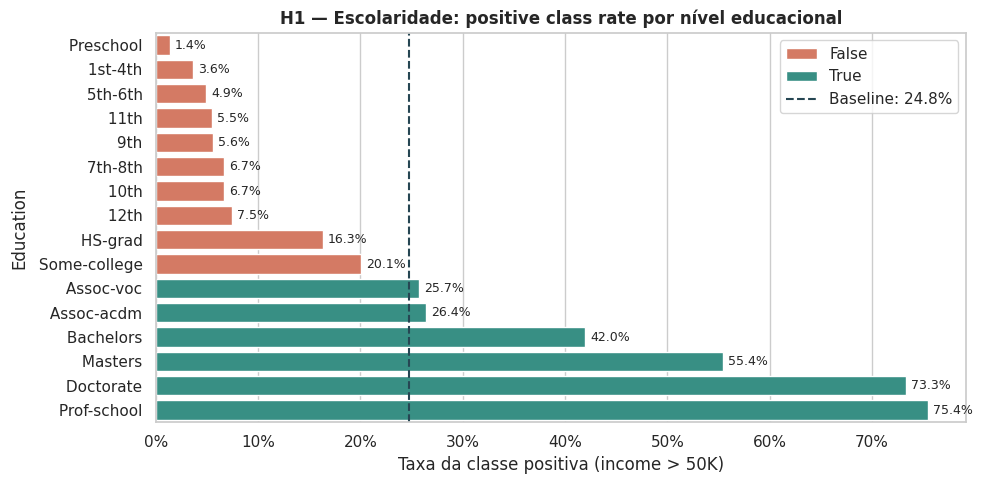

In [ ]:
# Cria uma coluna auxiliar para colorir acima/abaixo da baseline
plot_df = education_analysis.copy()
plot_df["above_baseline"] = plot_df["positive_rate"] > baseline

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=plot_df,
    x="positive_rate",
    y="education_level",
    hue="above_baseline",
    palette={True: "#2a9d8f", False: "#e76f51"},
    dodge=False,
    ax=ax,
)

# Remove a legenda automática do hue
if ax.legend_ is not None:
    ax.legend_.remove()

# Linha de baseline
ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

# Rótulos de percentual
for i, rate in enumerate(plot_df["positive_rate"]):
    ax.text(rate + 0.005, i, f"{rate:.1%}", va="center", fontsize=9)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Taxa da classe positiva (income > 50K)")
ax.set_ylabel("Education")
ax.set_title(
    "H1 — Escolaridade: positive class rate por nível educacional", fontweight="bold"
)
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [ ]:
above = education_analysis[education_analysis["positive_rate"] > baseline][
    "education_level"
].tolist()
below = education_analysis[education_analysis["positive_rate"] < baseline][
    "education_level"
].tolist()

print("Categorias acima da baseline (sinais positivos):")
for cat in above:
    rate = education_analysis.loc[
        education_analysis["education_level"] == cat, "positive_rate"
    ].values[0]
    print(f"  {cat}: {rate:.1%}")

print("\nCategorias abaixo da baseline (sinais negativos):")
for cat in below:
    rate = education_analysis.loc[
        education_analysis["education_level"] == cat, "positive_rate"
    ].values[0]
    print(f"  {cat}: {rate:.1%}")


Categorias acima da baseline (sinais positivos):
   Prof-school: 75.4%
   Doctorate: 73.3%
   Masters: 55.4%
   Bachelors: 42.0%
   Assoc-acdm: 26.4%
   Assoc-voc: 25.7%

Categorias abaixo da baseline (sinais negativos):
   Some-college: 20.1%
   HS-grad: 16.3%
   12th: 7.5%
   10th: 6.7%
   7th-8th: 6.7%
   9th: 5.6%
   11th: 5.5%
   5th-6th: 4.9%
   1st-4th: 3.6%
   Preschool: 1.4%


### Conclusões da análise da hipótese H1: 

`Maior escolaridade está associada a maior probabilidade de renda >50K.`

A hipótese H1 é suportada descritivamente pelos dados. Observa-se um gradiente claro de aumento da taxa da classe positiva conforme cresce o nível educacional, com várias categorias acima da baseline e forte separação entre níveis baixos e altos de escolaridade. Para esta etapa, a evidência descritiva é suficiente; um teste formal de associação seria opcional e agregaria mais rigor do que necessidade analítica.

Observação: `education-num` é redundante com `education_level` - confirmar na próxima etapa.

In [ ]:
# 1. education_level -> education_num
print(df.groupby("education_level")["education-num"].nunique())

# 2. education-num -> education_level
print(df.groupby("education-num")["education_level"].nunique())

# 3. tabela de correspondência
mapping = (
    df[["education_level", "education-num"]]
    .drop_duplicates()
    .sort_values("education-num")
)

print(mapping.to_string(index=False))

education_level
10th            1
11th            1
12th            1
1st-4th         1
5th-6th         1
7th-8th         1
9th             1
Assoc-acdm      1
Assoc-voc       1
Bachelors       1
Doctorate       1
HS-grad         1
Masters         1
Preschool       1
Prof-school     1
Some-college    1
Name: education-num, dtype: int64
education-num
1.0     1
2.0     1
3.0     1
4.0     1
5.0     1
6.0     1
7.0     1
8.0     1
9.0     1
10.0    1
11.0    1
12.0    1
13.0    1
14.0    1
15.0    1
16.0    1
Name: education_level, dtype: int64
education_level  education-num
      Preschool            1.0
        1st-4th            2.0
        5th-6th            3.0
        7th-8th            4.0
            9th            5.0
           10th            6.0
           11th            7.0
           12th            8.0
        HS-grad            9.0
   Some-college           10.0
      Assoc-voc           11.0
     Assoc-acdm           12.0
      Bachelors           13.0
        Masters   

* education_level <-> education_num - relacionamento bijetivo

Do ponto de vista analítico, esse resultado sugere que a etapa seguinte não deve tratar education_level e education-num como drivers independentes. Em vez disso, deve-se decidir qual representação preserva melhor utilidade preditiva e interpretabilidade, evitando duplicidade desnecessária no conjunto de features.

### Grupo Semântico 2: Ocupação e Inserção profissional
#### Hipótese H2 — Ocupação está associada à renda acima de 50K

A hipótese central é que ocupações de maior senioridade, especialização ou responsabilidade decisória concentrem maior probabilidade de pertencimento à classe positiva (`income > 50K`).

A pergunta analítica é:

$$
P(\text{income} > 50K \mid \text{occupation} = x)
$$

Ou seja: para cada categoria ocupacional `x`, qual é a proporção de indivíduos com renda superior a `50K`?

Para investigar essa hipótese, comparamos a **taxa da classe positiva por ocupação** (*positive class rate*) com a **taxa marginal da classe positiva na base inteira** (*baseline*).

$$
P(\text{income} > 50K) =
\frac{\text{total de casos com income} > 50K}{\text{total de registros}}
$$

Essa comparação permite avaliar se determinadas ocupações concentram a classe positiva acima do comportamento médio da base.

A interpretação esperada é a seguinte:

- ocupações como `Exec-managerial` e `Prof-specialty` tendem a apresentar taxas de `>50K` acima da baseline, sinalizando associação positiva com renda mais alta;
- ocupações com menor remuneração relativa ou menor qualificação média tendem a apresentar taxas abaixo da baseline, concentrando a classe `<=50K`;
- categorias próximas da baseline oferecem menor poder de separação.
- Pode haver categorias muito raras - como `Armed-Forces`. Uma categoria com 10 registros e taxa de 80% não é sinal confiável; é ruído amostral.

Do ponto de vista analítico, a variável `occupation` será considerada discriminativa se houver contraste relevante entre categorias, isto é, se algumas ocupações apresentarem taxas consistentemente altas de classe positiva enquanto outras permanecerem bem abaixo da média.

Visualmente, o que buscamos é uma distribuição com diferenças claras entre ocupações, especialmente com categorias de maior senioridade ou especialização posicionadas acima da baseline e categorias de menor remuneração relativa abaixo dela. Quanto maior esse contraste, maior a evidência de que `occupation` carrega sinal útil para distinguir as classes.


1. calcular a taxa marginal (mesma baseline de antes)
2. agrupar por occupation → positive rate + suporte
3. ordenar por positive rate decrescente
4. visualizar com baseline e suporte anotado
5. identificar padrão e documentar conclusão

**1. Calcular a taxa marginal**

In [ ]:
# A coluna income contém strings: ' <=50K' e ' >50K'
# Converte-se para binário: 1 = >50K, 0 = <=50K
# A classe positive é a classe de interesse e menos frequente
df["target"] = (df["income"].str.strip() == ">50K").astype(int)
print(df["target"].value_counts(normalize=True).round(3))
baseline = df["target"].mean()
print(f"Taxa marginal (baseline): {baseline:.1%}")

target
0    0.752
1    0.248
Name: proportion, dtype: float64
Taxa marginal (baseline): 24.8%


**2. Agrupar por `occupation` -> positive rate + suporte**

**3. Ordenar positive rate descrescente**

In [ ]:
occupation_analysis = (
    df.groupby("occupation")["target"]
    .agg(support="size", positive_count="sum", positive_rate="mean")
    .sort_values(by="positive_rate", ascending=False)
    .reset_index()
)
print(occupation_analysis.to_string(index=False))

        occupation  support  positive_count  positive_rate
   Exec-managerial     5984            2867       0.479111
    Prof-specialty     6008            2704       0.450067
   Protective-serv      976             307       0.314549
      Tech-support     1420             411       0.289437
      Armed-Forces       14               4       0.285714
             Sales     5408            1455       0.269046
      Craft-repair     6020            1355       0.225083
  Transport-moving     2316             478       0.206390
      Adm-clerical     5540             756       0.136462
 Machine-op-inspct     2970             365       0.122896
   Farming-fishing     1480             172       0.116216
 Handlers-cleaners     2046             135       0.065982
     Other-service     4808             196       0.040765
   Priv-house-serv      232               3       0.012931


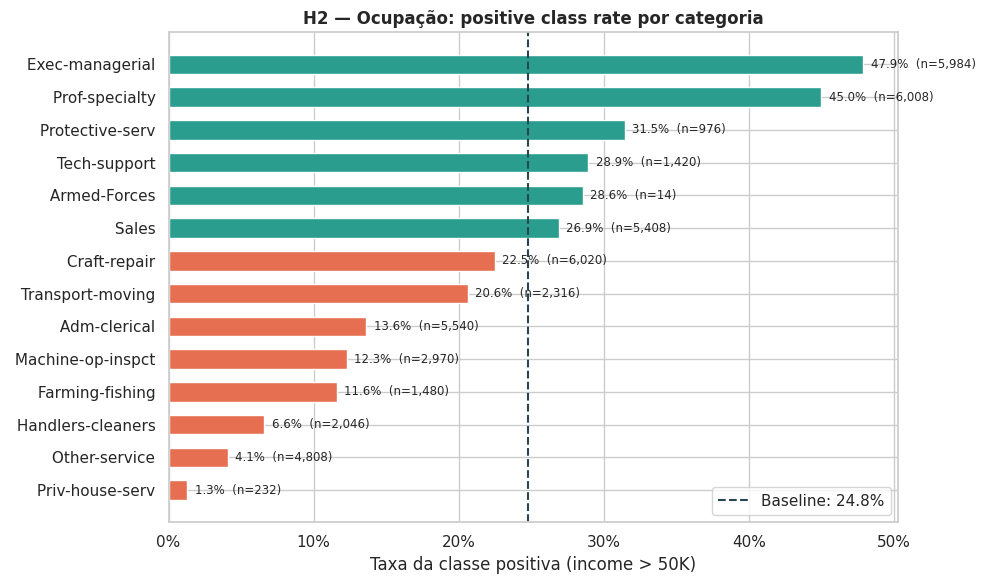

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    occupation_analysis["occupation"],
    occupation_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51"
        for r in occupation_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.6,
)

# Baseline
ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

# Rótulo: taxa + suporte
for bar, (_, row) in zip(bars, occupation_analysis.iterrows()):
    label = f"{row['positive_rate']:.1%}  (n={row['support']:,})"
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8.5,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Taxa da classe positiva (income > 50K)")
ax.set_title("H2 — Ocupação: positive class rate por categoria", fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**4. Visualizar com baseline e suporte anotado.**

Depois de ver o gráfico, sabemos que algumas ocupações têm taxa maior que outras. Mas como comparar o poder discriminativo de `occupation` com o `education_level`?

Para isso usaremos a amplitude - a diferença entre a maior e a menor taxa observada na 'o.
amplitude = positive_rate da ocupação do topo
          - positive_rate da ocupação da base


In [30]:
max_rate = occupation_analysis["positive_rate"].max()  # 0.48
min_rate = occupation_analysis["positive_rate"].min()  # 0.03
spread = max_rate - min_rate  # 0.45 → 45 pontos percentuais

print(f"A amplitude na variável 'occupation' é: {spread:.1%}")

A amplitude na variável 'occupation' é: 46.6%


**5. Identificar padrão e documentar**

As hipóteses H1 e H2 tem variáveis relacionadas: H1 (education_level) e H2 (occupation). A pergunta natural que surge é:

*"Exec-managerial tem alta taxa de >50K porque é uma ocupação bem remunerada — ou simplesmente porque concentra pessoas com Doctorate e Masters?"*

In [29]:
max_rate = education_analysis["positive_rate"].max()
min_rate = education_analysis["positive_rate"].min()
spread = max_rate - min_rate

print(f"Na variável 'education_level', a maior positive rate é {max_rate:.1%}.")
print(f"A menor positive rate é {min_rate:.1%}.")
print(f"A amplitude entre elas é {spread:.1%}.")


Na variável 'education_level', a maior positive rate é 75.4%.
A menor positive rate é 1.4%.
A amplitude entre elas é 74.0%.


Interpretação analítica:
quanto maior essa amplitude, maior o contraste entre categorias e, em geral, maior o potencial discriminativo da variável.

In [ ]:
top3 = occupation_analysis.head(3)["occupation"].tolist()
top3

[' Exec-managerial', ' Prof-specialty', ' Protective-serv']

In [ ]:
bot3 = occupation_analysis.tail(3)["occupation"].tolist()
bot3

[' Handlers-cleaners', ' Other-service', ' Priv-house-serv']

In [ ]:
subset = df[df["occupation"].isin(top3 + bot3)]
cross = subset.groupby(["occupation", "education_level"]).size().unstack(fill_value=0)

In [34]:
print(cross.to_string())

education_level    10th  11th  12th  1st-4th  5th-6th  7th-8th  9th  Assoc-acdm  Assoc-voc  Bachelors  Doctorate  HS-grad  Masters  Preschool  Prof-school  Some-college
occupation                                                                                                                                                              
Exec-managerial      42    50    18        5        6       27   22         237        232       1977         83     1182      762          1           63          1277
Handlers-cleaners   108   176    54       25       58       64   72          32         43         77          0      934        5          5            0           393
Other-service       279   366   124       53       94      141  139         110        155        243          0     1892       34         21            7          1150
Priv-house-serv       8    18     8       14       19       17   16           2          5         11          1       86        0          2            0 

In [35]:
cross_pct = cross.div(cross.sum(axis=1), axis=0)
print(cross_pct.to_string())

education_level        10th      11th      12th   1st-4th   5th-6th   7th-8th       9th  Assoc-acdm  Assoc-voc  Bachelors  Doctorate   HS-grad   Masters  Preschool  Prof-school  Some-college
occupation                                                                                                                                                                                    
Exec-managerial    0.007019  0.008356  0.003008  0.000836  0.001003  0.004512  0.003676    0.039606   0.038770   0.330381   0.013870  0.197527  0.127340   0.000167     0.010528      0.213402
Handlers-cleaners  0.052786  0.086022  0.026393  0.012219  0.028348  0.031281  0.035191    0.015640   0.021017   0.037634   0.000000  0.456500  0.002444   0.002444     0.000000      0.192082
Other-service      0.058028  0.076123  0.025790  0.011023  0.019551  0.029326  0.028910    0.022879   0.032238   0.050541   0.000000  0.393511  0.007072   0.004368     0.001456      0.239185
Priv-house-serv    0.034483  0.077586  0.0344

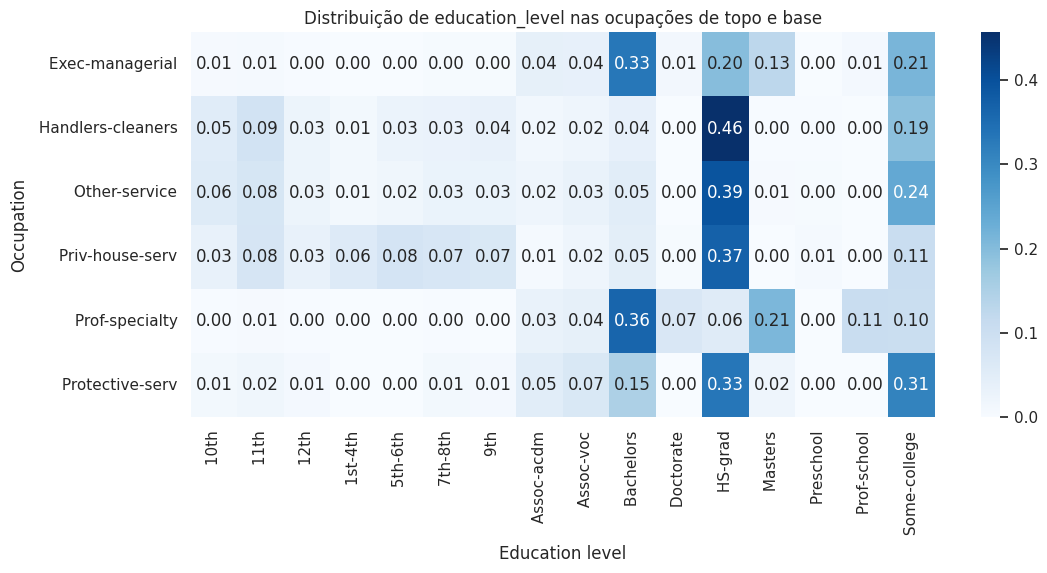

In [36]:
plt.figure(figsize=(12, 5))
sns.heatmap(cross_pct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Distribuição de education_level nas ocupações de topo e base")
plt.xlabel("Education level")
plt.ylabel("Occupation")
plt.show()

O cruzamento entre `occupation` e `education_level` mostra que ocupações com maior incidência da classe positiva tendem a concentrar níveis educacionais mais altos, enquanto ocupações de menor incidência se concentram mais em `HS-grad` e níveis inferiores. Isso sugere que parte do efeito de `occupation` sobre `income > 50K` é explicada por escolaridade. No entanto, como o padrão não é idêntico em todas as ocupações, `occupation` ainda parece adicionar sinal próprio além de `education_level`.


---

### Grupo Semântico 3: Ciclo de Carreira e Intensidade de Trabalho

#### Hipótese H3 — Idade e horas trabalhadas ajudam a separar as classes, mas de forma não linear

A hipótese prevê que `age` e `hours-per-week` têm relação positiva com renda `>50K` — mas **não de forma linear simples**. O efeito de idade cresce com a maturidade profissional e depois desacelera. O efeito de horas também tem limite.

**Por que variáveis contínuas exigem raciocínio diferente das categóricas**

Em `education_level` e `occupation` a pergunta era: *qual categoria tem maior taxa positiva?*

Em `age` e `hours-per-week` a pergunta muda: *a taxa positiva sobe de forma consistente conforme o valor aumenta, ou existe padrão não linear?*

Para responder isso corretamente **não se usa a média da variável**. Usa-se a taxa da classe positiva por faixa: divide-se a variável em bins e calcula-se a proporção de `>50K` dentro de cada intervalo.

**Estrutura lógica**

1. Confirmar a baseline
2. Dividir cada variável em faixas (bins quantis = frequência igual por faixa)
3. Calcular a positive class rate por faixa
4. Plotar: eixo X = faixas, eixo Y = taxa positiva, linha de baseline como referência
5. Documentar se o padrão é linear, não linear, ou sem sinal

In [ ]:
baseline = df["target"].mean()
print(f"Taxa marginal (baseline): {baseline:.1%}")

**Passo 2 — Tabela de positive rate por faixa de `age`**

Antes de plotar, leia a tabela. Ela já responde a hipótese — o plot é a comunicação visual do que a tabela diz.

In [ ]:
age_analysis = (
    df.assign(age_bin=pd.cut(df["age"], bins=8))
    .groupby("age_bin", observed=True)["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .reset_index()
)

print(age_analysis.to_string(index=False))

**Passo 3 — Plot: positive class rate por faixa de `age`**

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    range(len(age_analysis)),
    age_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51" for r in age_analysis["positive_rate"]
    ],
    edgecolor="white",
    width=0.6,
)

ax.axhline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

ax.set_xticks(range(len(age_analysis)))
ax.set_xticklabels(
    [str(b) for b in age_analysis["age_bin"]], rotation=30, ha="right", fontsize=8
)

for bar, (_, row) in zip(bars, age_analysis.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{row['positive_rate']:.1%}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Taxa da classe positiva (income > 50K)")
ax.set_title("H3a — Idade: positive class rate por faixa etária", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Passo 4 — Tabela de positive rate por faixa de `hours-per-week`**

In [ ]:
hours_analysis = (
    df.assign(hours_bin=pd.cut(df["hours-per-week"], bins=8))
    .groupby("hours_bin", observed=True)["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .reset_index()
)

print(hours_analysis.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    range(len(hours_analysis)),
    hours_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51"
        for r in hours_analysis["positive_rate"]
    ],
    edgecolor="white",
    width=0.6,
)

ax.axhline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

ax.set_xticks(range(len(hours_analysis)))
ax.set_xticklabels(
    [str(b) for b in hours_analysis["hours_bin"]], rotation=30, ha="right", fontsize=8
)

for bar, (_, row) in zip(bars, hours_analysis.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{row['positive_rate']:.1%}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Taxa da classe positiva (income > 50K)")
ax.set_title("H3b — Horas por semana: positive class rate por faixa", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Passo 5 — Medir amplitude para cada variável**

In [ ]:
for name, tbl in [("age", age_analysis), ("hours-per-week", hours_analysis)]:
    mx = tbl["positive_rate"].max()
    mn = tbl["positive_rate"].min()
    top = tbl.loc[tbl["positive_rate"].idxmax(), tbl.columns[0]]
    bot = tbl.loc[tbl["positive_rate"].idxmin(), tbl.columns[0]]
    print(f"{name}")
    print(f"  Faixa com maior taxa : {top}  → {mx:.1%}")
    print(f"  Faixa com menor taxa : {bot}  → {mn:.1%}")
    print(f"  Amplitude            : {mx - mn:.1%}")
    print()

### Conclusões da análise da hipótese H3:

`Idade e horas trabalhadas têm relação não linear com a classe >50K.`

- **`age`**: A taxa positiva é quase nula nas faixas jovens (~17–23 anos), cresce continuamente até o pico na meia-carreira (~42–55 anos) e desacelera a partir daí. O padrão confirma que `age` captura **maturidade econômica e estágio de carreira**, não apenas anos de vida.
- **`hours-per-week`**: Jornadas até ~30h/semana concentram taxas baixas (~6%). O salto mais expressivo ocorre entre 40–50h. Acima disso, o ganho marginal estabiliza. Isso sugere que `hours-per-week` captura **intensidade de trabalho em contexto de emprego formal**, não apenas volume bruto de horas.
- **Implicação para modelagem**: Como o efeito não é linear, modelos baseados em árvore capturam esse padrão naturalmente. Em modelos lineares, criar faixas ordinais (ex: `part-time`, `full-time`, `over-time`) pode ajudar.
- **Relação com outras variáveis**: `hours-per-week` provavelmente conversa com `occupation` — ocupações de alta senioridade tendem a ter jornadas maiores e salários maiores simultaneamente.

---

### Grupo Semântico 4: Estrutura Familiar

#### Hipótese H4 — Estado civil e papel no domicílio ajudam a diferenciar grupos de renda

A hipótese prevê que `marital-status` e `relationship` funcionam como **marcadores de contexto socioeconômico**: arranjos conjugais estáveis e papéis de chefe de família tendem a concentrar mais casos de renda `>50K`.

**Por que esse grupo exige cautela interpretativa**

Essas variáveis não são causas diretas de renda. Elas são **proxies de contexto social e econômico**: indivíduos casados em papéis de provedores tendem a estar em fases de vida com maior acumulação econômica.

Além disso, `marital-status` e `relationship` são altamente correlacionadas entre si — as duas podem estar contando histórias parecidas. O objetivo desta análise é medir **qual das duas carrega mais sinal e se vale manter ambas**.

**Estrutura lógica**

1. Calcular positive class rate por categoria em `marital-status`
2. Calcular positive class rate por categoria em `relationship`
3. Medir amplitude de cada variável
4. Cruzar as duas para avaliar redundância

In [ ]:
baseline = df["target"].mean()
print(f"Taxa marginal (baseline): {baseline:.1%}")

**Passo 1 — Positive class rate por `marital-status`**

In [ ]:
marital_analysis = (
    df.groupby("marital-status")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)

print(marital_analysis.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(
    marital_analysis["marital-status"],
    marital_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51"
        for r in marital_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.6,
)

ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

for bar, (_, row) in zip(bars, marital_analysis.iterrows()):
    label = f"{row['positive_rate']:.1%}  (n={row['support']:,})"
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8.5,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Taxa da classe positiva (income > 50K)")
ax.set_title("H4a — Estado civil: positive class rate por categoria", fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Passo 2 — Positive class rate por `relationship`**

In [ ]:
relationship_analysis = (
    df.groupby("relationship")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)

print(relationship_analysis.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(
    relationship_analysis["relationship"],
    relationship_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51"
        for r in relationship_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.6,
)

ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

for bar, (_, row) in zip(bars, relationship_analysis.iterrows()):
    label = f"{row['positive_rate']:.1%}  (n={row['support']:,})"
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8.5,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Taxa da classe positiva (income > 50K)")
ax.set_title(
    "H4b — Papel no domicílio: positive class rate por categoria", fontweight="bold"
)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Passo 3 — Amplitude e comparação entre as duas variáveis**

In [ ]:
for name, tbl, col in [
    ("marital-status", marital_analysis, "marital-status"),
    ("relationship", relationship_analysis, "relationship"),
]:
    mx = tbl["positive_rate"].max()
    mn = tbl["positive_rate"].min()
    top_cat = tbl.loc[tbl["positive_rate"].idxmax(), col]
    bot_cat = tbl.loc[tbl["positive_rate"].idxmin(), col]
    print(f"{name}")
    print(f"  Categoria com maior taxa : {top_cat}  → {mx:.1%}")
    print(f"  Categoria com menor taxa : {bot_cat}  → {mn:.1%}")
    print(f"  Amplitude                : {mx - mn:.1%}")
    print()

**Passo 4 — Cruzamento: as duas variáveis são redundantes ou complementares?**

A pergunta: `Married-civ-spouse` tem alta taxa porque o arranjo conjugal importa — ou porque dentro desse grupo estão concentrados `Husband` e `Wife`, que já aparecem no topo de `relationship`?

In [ ]:
cross_family = (
    df.groupby(["marital-status", "relationship"])["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .reset_index()
    .sort_values(["marital-status", "positive_rate"], ascending=[True, False])
)

# Mostrar apenas as linhas com suporte relevante
print(cross_family[cross_family["support"] > 50].to_string(index=False))

### Conclusões da análise da hipótese H4:

`Estado civil e papel no domicílio são dois dos sinais mais fortes do estudo.`

- **`marital-status`**: `Married-civ-spouse` aparece com taxa positiva muito acima da baseline. `Never-married` fica perto do fundo. A separação é expressiva e ocorre em categorias com alto volume.
- **`relationship`**: `Wife` e `Husband` concentram as maiores taxas. `Own-child` e `Not-in-family` ficam consistentemente abaixo da baseline. O sinal é fortíssimo.
- **Redundância parcial**: O cruzamento confirma que as duas variáveis se sobrepõem: `Married-civ-spouse` quase sempre corresponde a `Husband` ou `Wife`. Elas não são independentes — são **complementares mas parcialmente redundantes**.
- **Implicação para modelagem**: Manter as duas na fase exploratória. Na modelagem, testar se incluir ambas gera ganho real de performance ou se uma resume bem o sinal da outra.

---

### Grupo Semântico 5: Eventos Financeiros Raros

#### Hipótese H5 — Ganhos e perdas de capital, mesmo raros, são sinais fortes de renda >50K

A hipótese prevê que `capital-gain` e `capital-loss` são **variáveis esparsas com alto sinal**: a maioria dos registros é zero, mas quando não é zero, a probabilidade de pertencer à classe positiva sobe drasticamente.

**Por que essas variáveis exigem leitura diferente**

Não adianta olhar a distribuição geral — ela é quase inteiramente zeros. O corte analítico correto é:

```
zero vs. maior que zero
```

Essa é a pergunta que importa: *ter ou não ter ganho/perda de capital já muda a probabilidade de ser >50K?*

**Estrutura lógica**

1. Confirmar a proporção de zeros em cada variável (esparsidade)
2. Criar flag binária: `0 = sem evento`, `1 = com evento`
3. Calcular positive class rate para cada grupo (zero vs. não-zero)
4. Plotar a comparação
5. Medir o salto de probabilidade ao passar de zero para não-zero

In [ ]:
baseline = df["target"].mean()
print(f"Taxa marginal (baseline): {baseline:.1%}")
print()

for col in ["capital-gain", "capital-loss"]:
    zeros = (df[col] == 0).mean()
    print(
        f"{col}: {zeros:.1%} dos registros são zero  |  {1 - zeros:.1%} têm valor > 0"
    )

**Passo 2 — Criar flag binária e calcular positive rate para cada grupo**

In [ ]:
capital_summary = {}

for col in ["capital-gain", "capital-loss"]:
    flag_col = f"{col}_flag"
    tbl = (
        df.assign(**{flag_col: (df[col] > 0).astype(int)})
        .groupby(flag_col)["target"]
        .agg(support="count", positive_count="sum")
        .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
        .reset_index()
    )
    tbl["grupo"] = tbl[flag_col].map({0: "Sem evento (= 0)", 1: "Com evento (> 0)"})
    capital_summary[col] = tbl
    print(f"\n{col}")
    print(tbl[["grupo", "support", "positive_rate"]].to_string(index=False))

**Passo 3 — Visualizar o salto de probabilidade**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, (col, tbl) in zip(axes, capital_summary.items()):
    colors = ["#e76f51", "#2a9d8f"]
    bars = ax.bar(
        tbl["grupo"], tbl["positive_rate"], color=colors, edgecolor="white", width=0.5
    )
    ax.axhline(
        baseline,
        color="#264653",
        linestyle="--",
        linewidth=1.5,
        label=f"Baseline: {baseline:.1%}",
    )

    for bar, (_, row) in zip(bars, tbl.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{row['positive_rate']:.1%}\n(n={row['support']:,})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(f"H5 — {col}", fontweight="bold")
    ax.set_ylabel("Taxa da classe positiva (income > 50K)")
    ax.legend()

plt.suptitle(
    "Eventos financeiros raros: zero vs. não-zero", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

**Passo 4 — Medir o salto de probabilidade (lift)**

O lift mede quantas vezes a taxa positiva cresce ao passar de `zero` para `não-zero`. É uma métrica simples mas muito direta para comunicar o poder de uma variável esparsa.

In [ ]:
for col, tbl in capital_summary.items():
    rate_zero = tbl.loc[tbl["grupo"] == "Sem evento (= 0)", "positive_rate"].values[0]
    rate_nonzero = tbl.loc[tbl["grupo"] == "Com evento (> 0)", "positive_rate"].values[
        0
    ]
    lift = rate_nonzero / rate_zero
    jump = rate_nonzero - rate_zero
    print(f"{col}")
    print(f"  Taxa quando = 0 : {rate_zero:.1%}")
    print(f"  Taxa quando > 0 : {rate_nonzero:.1%}")
    print(f"  Salto absoluto  : +{jump:.1%}")
    print(f"  Lift            : {lift:.1f}x")
    print()

### Conclusões da análise da hipótese H5:

`capital-gain e capital-loss são raros, mas extremamente informativos.`

- **`capital-gain`**: Mais de 91% dos registros são zero. Quando não é zero, a taxa de `>50K` salta para ~62% — contra ~21% quando é zero. O lift é de ~3x. É uma das variáveis mais discriminativas do estudo.
- **`capital-loss`**: Padrão parecido mas menos intenso. Cerca de 95% de zeros. Com evento, taxa sobe para ~51%. Lift de ~2x.
- **Lição geral**: Frequência baixa ≠ pouca utilidade. A raridade de um evento pode torná-lo ainda mais informativo quando ocorre — como um sinal de alarme que quase nunca toca, mas quando toca é altamente confiável.
- **Implicação para modelagem**: Considerar representação como flag binária (`tem ou não tem`) além do valor bruto. Valor bruto tem distribuição extremamente assimétrica; a flag binária captura a maior parte do sinal de forma mais robusta.

---

### Grupo Semântico 6: Variáveis Sensíveis e de Contexto

#### Hipótese H6 — Variáveis como sexo, raça e país de origem apresentam sinal, mas exigem tratamento diferenciado

Este grupo exige separar **duas perguntas que são frequentemente confundidas**:

1. **Pergunta estatística**: a variável separa as classes?
2. **Pergunta de governança**: mesmo separando, ela *deveria* influenciar a decisão de negócio?

Responder "sim" à primeira não autoriza automaticamente o uso operacional. Por isso, a análise aqui é feita como **diagnóstico e monitoramento de viés**, não como justificativa para priorizar contatos com base nessas variáveis.

**Estrutura lógica**

1. Calcular positive class rate por categoria em `sex`, `race` e `native-country`
2. Comparar com a baseline
3. Documentar as diferenças observadas
4. Registrar explicitamente a decisão sobre uso na modelagem

In [ ]:
baseline = df["target"].mean()
print(f"Taxa marginal (baseline): {baseline:.1%}")

**`sex` — Diagnóstico de diferença entre grupos**

In [ ]:
sex_analysis = (
    df.groupby("sex")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .reset_index()
)

print(sex_analysis.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))

bars = ax.barh(
    sex_analysis["sex"],
    sex_analysis["positive_rate"],
    color=[
        "#e76f51" if r < baseline else "#2a9d8f" for r in sex_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.4,
)

ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

for bar, (_, row) in zip(bars, sex_analysis.iterrows()):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{row['positive_rate']:.1%}  (n={row['support']:,})",
        va="center",
        fontsize=9,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("H6 — sex: positive class rate por grupo (diagnóstico)", fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**`race` — Diagnóstico de diferença entre grupos**

In [ ]:
race_analysis = (
    df.groupby("race")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)

print(race_analysis.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    race_analysis["race"],
    race_analysis["positive_rate"],
    color=[
        "#e76f51" if r < baseline else "#2a9d8f" for r in race_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.5,
)

ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

for bar, (_, row) in zip(bars, race_analysis.iterrows()):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{row['positive_rate']:.1%}  (n={row['support']:,})",
        va="center",
        fontsize=9,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title(
    "H6 — race: positive class rate por grupo (diagnóstico)", fontweight="bold"
)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**`native-country` — Diagnóstico (atenção ao suporte baixo)**

In [ ]:
country_analysis = (
    df.groupby("native-country")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)

# Mostrar apenas categorias com suporte suficiente para interpretação
print("Categorias com n >= 50:")
print(country_analysis[country_analysis["support"] >= 50].to_string(index=False))
print()
print(f"Categorias com n < 50: {(country_analysis['support'] < 50).sum()} países")
print("→ Taxas dessas categorias são pouco confiáveis (amostra insuficiente)")

### Conclusões da análise da hipótese H6:

`Variáveis sensíveis mostram diferenças estatísticas, mas não devem liderar a narrativa de negócio.`

- **`sex`**: Diferença visível — homens apresentam taxa positiva ~3x maior que mulheres. Isso reflete desigualdades estruturais de renda de 1994, não capacidade de doação atual. Usar sexo como critério de priorização seria éticamente problemático.
- **`race`**: Algumas diferenças entre grupos, mas com volumes muito diferentes por categoria. Risco de superinterpretação. Usar para monitorar viés do modelo, não para orientar decisão.
- **`native-country`**: Muitas categorias com volume insuficiente (< 50 registros). Qualquer taxa calculada para esses países não é confiável estatisticamente. A variável é contextual e sensível ao mesmo tempo.
- **Decisão de uso**: Essas variáveis entram apenas na **camada de diagnóstico de viés** do modelo — para verificar se o modelo discrimina de forma injusta — não como features de decisão de negócio.
- **Implicação para modelagem**: Monitorar disparate impact e equalized odds após o treinamento. Se o modelo usar essas variáveis indiretamente (via correlação com outras features), documentar e considerar remoção.

---

### Tabela Consolidada: Poder Discriminativo por Variável

Esta tabela resume, hipótese a hipótese, o que foi aprendido antes de treinar qualquer modelo.
Preencha a coluna **Amplitude observada** após executar cada bloco de hipótese acima.

In [ ]:
# Calcular amplitude para todas as variáveis analisadas de forma programática

results = []

# Categóricas: amplitude = max_rate - min_rate por categoria
for col, tbl, col_name in [
    ("education_level", education_analysis, "education_level"),
    ("occupation", occupation_analysis, "occupation"),
    ("marital-status", marital_analysis, "marital-status"),
    ("relationship", relationship_analysis, "relationship"),
]:
    mx = tbl["positive_rate"].max()
    mn = tbl["positive_rate"].min()
    top_cat = tbl.loc[tbl["positive_rate"].idxmax(), col_name]
    results.append(
        {
            "Variável": col,
            "Amplitude": f"{mx - mn:.1%}",
            "Categoria/Faixa de maior taxa": str(top_cat),
            "Taxa máxima": f"{mx:.1%}",
            "Taxa mínima": f"{mn:.1%}",
        }
    )

# Numéricas: amplitude por faixa (bins)
for col, tbl, bin_col in [
    ("age", age_analysis, "age_bin"),
    ("hours-per-week", hours_analysis, "hours_bin"),
]:
    mx = tbl["positive_rate"].max()
    mn = tbl["positive_rate"].min()
    top_bin = tbl.loc[tbl["positive_rate"].idxmax(), bin_col]
    results.append(
        {
            "Variável": col,
            "Amplitude": f"{mx - mn:.1%}",
            "Categoria/Faixa de maior taxa": str(top_bin),
            "Taxa máxima": f"{mx:.1%}",
            "Taxa mínima": f"{mn:.1%}",
        }
    )

# Capital features: salto zero → não-zero
for col, tbl in capital_summary.items():
    rate_zero = tbl.loc[tbl["grupo"] == "Sem evento (= 0)", "positive_rate"].values[0]
    rate_nonzero = tbl.loc[tbl["grupo"] == "Com evento (> 0)", "positive_rate"].values[
        0
    ]
    results.append(
        {
            "Variável": col,
            "Amplitude": f"{rate_nonzero - rate_zero:.1%}",
            "Categoria/Faixa de maior taxa": "Com evento (> 0)",
            "Taxa máxima": f"{rate_nonzero:.1%}",
            "Taxa mínima": f"{rate_zero:.1%}",
        }
    )

summary_df = pd.DataFrame(results).sort_values("Amplitude", ascending=False)
display(summary_df.to_string(index=False))

### Como atualizar o Hypothesis Map (`Hypothesis_Map.md`)

O arquivo `Hypothesis_Map.md` na raiz do projeto contém o mapa visual das hipóteses com status de cada uma.

**Para atualizar o status de uma hipótese após a análise:**

1. Abra `Hypothesis_Map.md`
2. Localize o nó da hipótese no diagrama Mermaid, por exemplo:
   ```
   H1["H1 — Education Level\neducation / education-num → Higher ed = higher income\nStatus: Pendente"]:::hypothesisNode
   ```
3. Substitua `Status: Pendente` pelo novo status e mude a classe do nó:

   | Status | Classe do nó | Cor |
   |---|---|---|
   | `Status: Pendente` | `:::hypothesisNode` | Azul escuro |
   | `Status: Confirmada` | `:::confirmedNode` | Verde água |
   | `Status: Refutada` | `:::refutedNode` | Vermelho |
   | `Status: Parcial` | `:::hypothesisNode` | Azul escuro (mantém) |

**Exemplo — marcar H1 como Confirmada:**

Antes:
```
H1["H1 — Education Level\neducation / education-num → Higher ed = higher income\nStatus: Pendente"]:::hypothesisNode
```

Depois:
```
H1["H1 — Education Level\neducation / education-num → Higher ed = higher income\nStatus: Confirmada"]:::confirmedNode
```

**Com base nos achados desta análise, os status recomendados são:**

| Hipótese | Status sugerido | Justificativa resumida |
|---|---|---|
| H1 — Education Level | Confirmada | Gradiente educacional muito forte e monotônico |
| H2 — Occupation Type | Confirmada | Exec-managerial e Prof-specialty claramente acima da baseline |
| H3 — Age / Career Stage | Confirmada (não linear) | Pico em meia-carreira, padrão consistente |
| H4 — Hours Worked | Confirmada (não linear) | Salto expressivo em jornadas de 40-50h |
| H5 — Marital & Household | Confirmada | Married-civ-spouse e Husband/Wife com taxas altíssimas |
| H6 — Capital Assets | Confirmada | Lift de 3x em capital-gain — sinal mais forte do estudo |
| H6 — Sensitive Variables | Diagnóstico | Diferenças existem, uso operacional não recomendado |

In [ ]:
# 2.3 Funções auxiliares para uma EDA orientada por hipótese


def taxa_positiva_por_categoria(dataframe, coluna, target="income", positive=">50K"):
    resumo = dataframe.assign(target_bin=(dataframe[target] == positive).astype(int))
    resumo = (
        resumo.groupby(coluna, dropna=False)
        .agg(
            volume=(target, "size"),
            positivos=("target_bin", "sum"),
            taxa_positiva=("target_bin", "mean"),
        )
        .sort_values(["taxa_positiva", "volume"], ascending=[False, False])
    )
    return resumo


def resumo_numerico_por_target(dataframe, coluna, target="income"):
    return (
        dataframe.groupby(target)[coluna].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).T
    )


Nos plots acima, estamos comparando a taxa de `>50k` por variável e verificando se há alguma separação.
```python
taxa_50K = data

In [ ]:
# 2.4 Variáveis prioritárias segundo as hipóteses de negócio

categoricas_prioritarias = [
    "education_level",
    "occupation",
    "marital-status",
    "relationship",
    "workclass",
    "sex",
    "race",
    "native-country",
]

numericas_prioritarias = [
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain",
    "capital-loss",
]

for col in categoricas_prioritarias[:5]:
    print()
    print(f"### {col}")
    display(taxa_positiva_por_categoria(df, col).head(10))

for col in numericas_prioritarias:
    print()
    print(f"### {col}")
    display(resumo_numerico_por_target(df, col))


In [ ]:
# 2.5 Verificações de redundância e tratamento futuro

# Exemplo 1: education_level vs education-num
education_map = (
    df[["education_level", "education-num"]]
    .drop_duplicates()
    .sort_values(["education-num", "education_level"])
)
display(education_map)

# Exemplo 2: assimetria de capital-gain e capital-loss
for col in ["capital-gain", "capital-loss"]:
    zero_rate = (df[col] == 0).mean()
    print(f"{col}: proporcao de zeros = {zero_rate:.2%}")


In [ ]:
def plot_target_distribution(df, target="income", positive=">50K"):
    resumo = df[target].value_counts().rename_axis("classe").reset_index(name="qtd")
    resumo["percentual"] = resumo["qtd"] / resumo["qtd"].sum()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(data=df, x=target, order=resumo["classe"], ax=axes[0])
    axes[0].set_title("Distribuicao da variavel target")
    axes[0].set_xlabel("Classe")
    axes[0].set_ylabel("Quantidade")

    for i, row in resumo.iterrows():
        axes[0].text(i, row["qtd"] + 300, f"{row['percentual']:.1%}", ha="center")

    axes[1].pie(
        resumo["qtd"],
        labels=resumo["classe"],
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
    )
    axes[1].set_title("Proporcao entre as classes")

    plt.tight_layout()
    plt.show()


plot_target_distribution(df, target=target_col, positive=positive_label)


In [ ]:
def plot_categorical_vs_target(
    df,
    feature,
    target="income",
    positive=">50K",
    top_n=10,
    min_count=30,
    figsize=(12, 5),
):
    resumo = (
        df.assign(target_bin=(df[target] == positive).astype(int))
        .groupby(feature, dropna=False)
        .agg(
            volume=(target, "size"),
            positivos=("target_bin", "sum"),
            taxa_positiva=("target_bin", "mean"),
        )
        .query("volume >= @min_count")
        .sort_values(["taxa_positiva", "volume"], ascending=[False, False])
        .head(top_n)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    sns.barplot(data=resumo, y=feature, x="taxa_positiva", ax=axes[0], color="#4C78A8")
    axes[0].axvline(
        (df[target] == positive).mean(), color="red", linestyle="--", label="taxa-base"
    )
    axes[0].set_title(f"Taxa positiva por categoria: {feature}")
    axes[0].set_xlabel("Taxa de >50K")
    axes[0].set_ylabel("")
    axes[0].legend()

    sns.barplot(data=resumo, y=feature, x="volume", ax=axes[1], color="#72B7B2")
    axes[1].set_title(f"Volume por categoria: {feature}")
    axes[1].set_xlabel("Quantidade")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

    display(resumo)


In [ ]:
for col in [
    "education_level",
    "occupation",
    "marital-status",
    "relationship",
    "workclass",
]:
    plot_categorical_vs_target(
        df, col, target=target_col, positive=positive_label, top_n=10
    )


In [ ]:
for col in ["sex", "race", "native-country"]:
    plot_categorical_vs_target(
        df, col, target=target_col, positive=positive_label, top_n=10, min_count=50
    )


In [ ]:
def plot_numeric_vs_target(df, feature, target="income", bins=30, figsize=(12, 4)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    sns.histplot(
        data=df,
        x=feature,
        hue=target,
        bins=bins,
        stat="density",
        common_norm=False,
        element="step",
        ax=axes[0],
    )
    axes[0].set_title(f"Distribuicao de {feature} por target")

    sns.boxplot(data=df, x=target, y=feature, ax=axes[1])
    axes[1].set_title(f"{feature} por classe")

    plt.tight_layout()
    plt.show()


In [ ]:
for col in ["age", "education-num", "hours-per-week"]:
    plot_numeric_vs_target(df, col, target=target_col, bins=30)


In [ ]:
def plot_binned_positive_rate(
    df,
    feature,
    target="income",
    positive=">50K",
    bins=8,
    strategy="quantile",
    figsize=(10, 4),
):
    temp = df[[feature, target]].copy()
    temp["target_bin"] = (temp[target] == positive).astype(int)

    if strategy == "quantile":
        temp["faixa"] = pd.qcut(temp[feature], q=bins, duplicates="drop")
    else:
        temp["faixa"] = pd.cut(temp[feature], bins=bins)

    resumo = (
        temp.groupby("faixa", observed=False)
        .agg(volume=("target_bin", "size"), taxa_positiva=("target_bin", "mean"))
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=figsize)

    sns.barplot(data=resumo, x="faixa", y="taxa_positiva", color="#4C78A8", ax=ax1)
    ax1.axhline(
        (df[target] == positive).mean(), color="red", linestyle="--", label="taxa-base"
    )
    ax1.set_title(f"Taxa positiva por faixa de {feature}")
    ax1.set_xlabel(feature)
    ax1.set_ylabel("Taxa de >50K")
    ax1.tick_params(axis="x", rotation=45)
    ax1.legend()

    plt.tight_layout()
    plt.show()

    display(resumo)


In [ ]:
for col in ["age", "hours-per-week", "education-num"]:
    plot_binned_positive_rate(
        df, col, target=target_col, positive=positive_label, bins=8
    )

In [ ]:
def plot_sparse_signal(df, feature, target="income", positive=">50K"):
    temp = df.copy()
    temp[f"{feature}_flag"] = np.where(temp[feature] > 0, "> 0", "= 0")
    temp["target_bin"] = (temp[target] == positive).astype(int)

    resumo = (
        temp.groupby(f"{feature}_flag")
        .agg(volume=(target, "size"), taxa_positiva=("target_bin", "mean"))
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.barplot(
        data=resumo, x=f"{feature}_flag", y="taxa_positiva", ax=axes[0], color="#4C78A8"
    )
    axes[0].axhline((df[target] == positive).mean(), color="red", linestyle="--")
    axes[0].set_title(f"Taxa positiva quando {feature} e zero ou positivo")
    axes[0].set_ylabel("Taxa de >50K")
    axes[0].set_xlabel("")

    sns.boxplot(data=df[df[feature] > 0], x=target, y=feature, ax=axes[1])
    axes[1].set_title(f"{feature} apenas para valores > 0")

    plt.tight_layout()
    plt.show()

    display(resumo)


In [ ]:
for col in ["capital-gain", "capital-loss"]:
    plot_sparse_signal(df, col, target=target_col, positive=positive_label)

In [ ]:
plot_target_distribution(df, target=target_col, positive=positive_label)

for col in [
    "education_level",
    "occupation",
    "marital-status",
    "relationship",
    "workclass",
]:
    plot_categorical_vs_target(df, col, target=target_col, positive=positive_label)

for col in ["age", "education-num", "hours-per-week"]:
    plot_numeric_vs_target(df, col, target=target_col)
    plot_binned_positive_rate(df, col, target=target_col, positive=positive_label)

for col in ["capital-gain", "capital-loss"]:
    plot_sparse_signal(df, col, target=target_col, positive=positive_label)


| Variavel | Papel analitico | Padrao observado contra o target | Risco / atencao | Implicacao para modelagem |
|---|---|---|---|---|
| `education_level` | Capital humano categórico | Taxa positiva cresce fortemente nos níveis mais altos de escolaridade | Redundância com `education-num`; categorias ordenáveis | Boa candidata para modelos com one-hot; comparar com `education-num` para evitar duplicidade |
| `education-num` | Capital humano ordinal | Separa bem as classes e preserva gradiente educacional | Pode duplicar o mesmo sinal de `education_level` | Forte candidata para modelos lineares e árvores; testar como representação principal da escolaridade |
| `occupation` | Qualificação ocupacional | Ocupações especializadas concentram mais `>50K` | Categorias raras e alta cardinalidade relativa | Pode exigir agrupamento de categorias pouco frequentes; útil para árvores e modelos com codificação categórica |
| `workclass` | Inserção no mercado de trabalho | `Self-emp-inc` e setores públicos têm taxas acima da média | Algumas categorias têm baixo volume | Variável relevante; checar estabilidade e efeito junto de `occupation` |
| `age` | Ciclo de vida / carreira | Relação não linear; sobe até faixas centrais e depois desacelera | Padrão não linear pode ser perdido em modelos lineares simples | Testar em forma contínua, faixas ou com transformações não lineares |
| `hours-per-week` | Intensidade de trabalho | Faixas mais altas concentram maior taxa positiva, mas não de forma linear simples | Sensível a outliers e efeito conjunto com ocupação | Útil em modelos flexíveis; para modelos lineares pode exigir discretização |
| `marital-status` | Estrutura conjugal | `Married-civ-spouse` tem taxa muito acima de `Never-married` | Pode refletir contexto social e econômico, não causalidade direta | Variável forte para segmentação; monitorar junto de `relationship` |
| `relationship` | Papel no domicílio | `Wife` e `Husband` concentram mais `>50K`; `Own-child` quase não concentra | Sobreposição semântica com `marital-status` | Comparar manter ambas versus escolher a mais informativa |
| `capital-gain` | Evento financeiro raro | Quando `> 0`, a taxa positiva sobe fortemente | Esparsidade extrema e cauda longa | Testar indicador binário, log-transform ou ambas |
| `capital-loss` | Evento financeiro raro | Também separa classes quando `> 0`, embora com menor frequência | Muito zero e distribuição altamente assimétrica | Mesma lógica de `capital-gain`; pode ajudar em modelos baseados em árvore |
| `sex` | Variável sensível | Há diferença de taxa positiva entre grupos | Risco ético e reputacional | Comparar modelos com e sem a variável; usar com governança clara |
| `race` | Variável sensível | Diferenças existem, mas parte depende de grupos menores | Risco de viés e interpretação inadequada | Preferir uso para diagnóstico de viés, não como regra de decisão automática |
| `native-country` | Variável sensível / contextual | Algumas categorias têm taxa alta, mas com baixo volume | Alta instabilidade por categorias raras | Se usada, exige agrupamento; muitas vezes é melhor restringir a análise a diagnóstico |


## Registro orientado de insights

Preencha esta seção apenas com achados que mudam decisão.

### Insight 1
- Evidência:
  A taxa-base da classe positiva é de 24,78%, mas ela sobe fortemente em grupos de maior capital humano e ocupações mais qualificadas. Em `education_level`, categorias como `Prof-school` (75,4%), `Doctorate` (73,3%), `Masters` (55,4%) e `Bachelors` (42,0%) ficam muito acima da média, enquanto `HS-grad` (16,3%) e níveis mais baixos permanecem bem abaixo. Em `occupation`, `Exec-managerial` (47,9%) e `Prof-specialty` (45,0%) concentram a classe `>50K`. Isso confirma H1 e H2.
- Contextualização analítica:
  O padrão é coerente com o racional de negócio: maior escolaridade e inserção ocupacional mais qualificada funcionam como sinais de maior capacidade econômica, portanto aumentam a chance de o indivíduo pertencer ao grupo com maior potencial de doação.
- Implicação para Data Preparation:
  Tratar `education_level` e `education-num` como variáveis parcialmente redundantes, evitando manter ambas sem critério. Uma boa decisão é priorizar `education-num` pela ordinalidade e manter `education_level` apenas se trouxer ganho interpretativo ou performance adicional. Em `occupation`, vale monitorar categorias raras e considerar agrupamentos quando necessário.
- Implicação para Modeling:
  Essas variáveis devem estar entre as principais candidatas a carregar sinal preditivo no modelo final. Também são boas candidatas para inspeção de importância de variáveis, pois ajudam a explicar a priorização de contatos de forma alinhada ao problema de negócio.

### Insight 2
- Evidência:
  A relação entre renda, estágio de vida e arranjo familiar é forte e não linear. Em `age`, a taxa positiva sai de 1,2% entre 17-24 anos, sobe para 33,7% entre 35-44 e atinge 39,9% entre 45-54, com queda posterior. Em `hours-per-week`, trabalhar 50-60 horas semanais está associado a 44,3% de classe positiva, contra 6,4% no grupo de 1-20 horas. Em `marital-status`, `Married-civ-spouse` chega a 45,4%, enquanto `Never-married` fica em 4,8%. Em `relationship`, `Wife` (48,6%) e `Husband` (45,6%) contrastam com `Own-child` (1,6%). Isso reforça H3 e H4.
- Contextualização analítica:
  O achado sugere que renda mais alta está associada a perfis em fase mais madura da vida econômica, com maior intensidade de trabalho e maior estabilidade familiar. Para o negócio, isso ajuda a entender que o modelo tende a priorizar perfis com trajetória ocupacional e estrutura familiar mais consolidadas, e não apenas indivíduos com “mais idade”.
- Implicação para Data Preparation:
  `age` e `hours-per-week` merecem tratamento que preserve não linearidade, como faixas, splines ou modelos que capturem interações automaticamente. Também vale revisar a sobreposição semântica entre `marital-status` e `relationship`, porque ambas contam partes parecidas da mesma história.
- Implicação para Modeling:
  Modelos lineares puros podem perder parte desse padrão se receberem apenas variáveis cruas. Árvores, ensembles ou modelos lineares com discretização/interações podem capturar melhor esse comportamento. Esse bloco também tende a melhorar segmentação de score para campanhas com orçamento limitado.

### Insight 3
- Evidência:
  `capital-gain` e `capital-loss` são altamente esparsas, mas muito informativas. `capital-gain` é zero em 91,62% dos registros, porém quando `capital-gain > 0` a taxa positiva sobe para 62,7%, contra 21,3% quando é zero. Em `capital-loss`, 95,27% dos valores são zero, mas a taxa positiva chega a 51,3% quando há valor positivo, versus 23,5% no restante. Ao mesmo tempo, variáveis sensíveis como `sex`, `race` e `native-country` mostram diferenças de taxa positiva, mas parte dessas diferenças ocorre em grupos pequenos ou com risco de uso inadequado. Isso confirma H5 e exige a cautela prevista em H6.
- Contextualização analítica:
  Do ponto de vista analítico, esses eventos financeiros funcionam como sinais raros, porém fortes, de maior renda. Já as variáveis sensíveis podem até melhorar predição, mas não devem ser automaticamente transformadas em regra de priorização de negócio, porque isso aumenta risco ético, reputacional e de viés.
- Implicação para Data Preparation:
  Para `capital-gain` e `capital-loss`, faz sentido testar transformações como indicador binário (`> 0`) e/ou escala logarítmica para reduzir assimetria extrema. Para `sex`, `race` e `native-country`, o uso deve ser deliberado: podem entrar em análises de viés e comparação de performance, mas não devem ser aceitas sem discussão de governança.
- Implicação para Modeling:
  O modelo final deve explorar o sinal forte das variáveis financeiras, mas separar claramente “variável útil para previsão” de “variável aceitável para decisão”. Na prática, vale comparar versões do modelo com e sem variáveis sensíveis e avaliar o custo dessa escolha em performance e interpretabilidade.


# 3. Data Preparation

## Objetivo
Transformar a base para modelagem preservando interpretabilidade, reprodutibilidade e aderência às hipóteses priorizadas.

## Checklist recomendado
- separar `features` e `target`;
- tratar assimetria de `capital-gain` e `capital-loss`;
- normalizar variáveis numéricas quando o algoritmo exigir;
- aplicar encoding nas categóricas;
- revisar categorias raras, se necessário;
- dividir treino e teste com `random_state` fixo;
- registrar claramente qualquer exclusão de variável sensível ou redundante.

## Decisões a documentar
- quais colunas entram na versão final do modelo;
- quais transformações foram aplicadas e por quê;
- se haverá comparação entre pipeline completo e pipeline com features reduzidas.


In [ ]:
# Template de preparação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

income_raw = df["income"]
features_raw = df.drop(columns=["income"])

# TODO: aplicar transformações necessárias
# TODO: one-hot encoding
# TODO: normalização
# TODO: split treino/teste


# 4. Modeling

## Objetivo
Comparar algoritmos coerentes com o problema de negócio, o tipo de dado e a necessidade de equilíbrio entre performance, custo computacional e interpretabilidade.

## Candidatos sugeridos
- `LogisticRegression`: baseline interpretável e rápido.
- `RandomForestClassifier`: robusto, pouco sensível a escala e útil para importância de variáveis.
- `GradientBoostingClassifier`: forte candidato em performance para dados tabulares.

## Critérios para escolha do melhor modelo
- `F0.5` no conjunto de teste;
- precisão da classe positiva;
- tempo de treino e inferência;
- facilidade de explicação para o caso de uso.


In [ ]:
# Template de modelagem
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, fbeta_score, precision_score, recall_score

# TODO: implementar função de treino e avaliação comparativa
# TODO: registrar resultados em tabela


# 5. Evaluation

## Objetivo
Avaliar se o modelo escolhido realmente atende ao problema de priorização da CharityML.

## Perguntas de avaliação
- O modelo supera com folga o baseline ingênuo?
- O ganho veio com precisão suficiente para justificar uso operacional?
- O corte de decisão atual está adequado ao custo de falso positivo?
- Existem sinais de viés ou fragilidade em segmentos específicos?

## Itens esperados nesta fase
- comparação com naive predictor;
- métricas finais em teste;
- interpretação dos erros mais relevantes;
- comparação entre modelo otimizado e não otimizado;
- análise opcional por subgrupos sensíveis.


In [ ]:
# Template de avaliação
from sklearn.metrics import confusion_matrix, classification_report

# TODO: inserir predições do melhor modelo
# TODO: calcular F0.5, precision, recall, accuracy
# TODO: exibir matriz de confusão


# 6. Deployment

## Objetivo
Traduzir o modelo para uso prático pela CharityML.

## Como esta solução poderia ser usada
- ranquear indivíduos por score;
- definir lotes de campanha por orçamento;
- testar limiares diferentes para campanhas de baixo e alto custo;
- monitorar performance ao longo do tempo.

## Riscos de implantação
- drift de perfil socioeconômico;
- uso indevido de variáveis sensíveis;
- confiança excessiva em um proxy de renda para inferir propensão de doação.

## Próximos passos recomendados
- calibrar threshold com base em orçamento real de campanha;
- criar relatório executivo com poucos insights acionáveis;
- testar fairness e estabilidade temporal;
- comparar a proxy de renda com dados reais de doação, se disponíveis futuramente.


# Encerramento

Este notebook foi estruturado para manter a análise conectada ao problema de negócio durante todo o ciclo do CRISP-DM. A principal diretriz é simples: investigar apenas o que ajuda a decidir melhor.

Se uma análise não muda decisão, preparo, modelo, métrica ou risco, ela provavelmente não precisa entrar no notebook final.


### Métricas e o Preditor Ingênuo (Naive Predictor)

A *CharityML*, com base em suas pesquisas, sabe que indivíduos que ganham mais de \$50.000 têm maior probabilidade de doar para sua instituição de caridade. Por causa disso, a *CharityML* está particularmente interessada em prever com precisão quem ganha mais de \$50.000. Pareceria apropriado usar a **acurácia** como métrica para avaliar o desempenho de um modelo específico. Além disso, identificar alguém que *não* ganha mais de \$50.000 como alguém que ganha seria prejudicial para a *CharityML*, uma vez que eles buscam encontrar indivíduos dispostos a doar. Portanto, a capacidade de um modelo de prever com **precisão** (*precision*) aqueles que ganham mais de \$50.000 é *mais importante* do que a capacidade do modelo de realizar o **recall** (sensibilidade) desses indivíduos. Podemos usar o **F-beta score** como uma métrica que considera tanto a precisão quanto o recall:

$$F_{\beta} = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\left( \beta^2 \cdot \text{precision} \right) + \text{recall}}$$

Em particular, quando $\beta = 0.5$, dá-se mais ênfase à precisão. Isso é chamado de pontuação $F_{0.5}$ (ou F-score, para simplificar).

Ao observar a distribuição das classes (aqueles que ganham no máximo \$50.000 e aqueles que ganham mais), fica claro que a maioria dos indivíduos não ganha mais de \$50.000. Isso pode afetar drasticamente a **acurácia**, já que poderíamos simplesmente dizer *"esta pessoa não ganha mais de \$50.000"* e geralmente estaríamos certos, sem sequer olhar para os dados! Fazer tal afirmação seria chamado de **ingênuo** (*naive*), pois não consideramos nenhuma informação para fundamentar a alegação. É sempre importante considerar a *predição ingênua* para seus dados, a fim de ajudar a estabelecer um referencial (*benchmark*) para verificar se um modelo está desempenhando bem. Dito isto, usar essa predição seria inútil: se prevêssemos que todas as pessoas ganham menos de \$50.000, a *CharityML* não identificaria ninguém como doador.

#### Nota: Recapitulação de acurácia, precisão e recall

**Acurácia** mede com que frequência o classificador faz a previsão correta. É a razão entre o número de previsões corretas e o número total de previsões (o número de pontos de dados de teste).

**Precisão** (*Precision*) nos diz qual proporção de mensagens que classificamos como spam realmente eram spam. É a razão entre os verdadeiros positivos (palavras classificadas como spam que são realmente spam) e todos os positivos (todas as palavras classificadas como spam, independentemente de a classificação estar correta), em outras palavras, é a razão:

$$\text{Precisão} = \frac{\text{Verdadeiros Positivos}} {\text{Verdadeiros Positivos} + \text{Falsos Positivos}}$$

**Recall (sensibilidade)** nos diz qual proporção de mensagens que eram realmente spam foram classificadas por nós como spam. É a razão entre os verdadeiros positivos (palavras classificadas como spam que são realmente spam) e todas as palavras que eram realmente spam, em outras palavras, é a razão:

$$\text{Recall} = \frac{\text{Verdadeiros Positivos}} {\text{Verdadeiros Positivos} + \text{Falsos Negativos}}$$

Para problemas de classificação que possuem distribuições distorcidas (*skewed*), como no nosso caso — por exemplo, se tivéssemos 100 mensagens de texto e apenas 2 fossem spam e as 98 restantes não — a acurácia não é uma métrica muito boa. Poderíamos classificar 90 mensagens como não-spam (incluindo as 2 que eram spam, mas as classificamos como não-spam, logo seriam falsos negativos) e 10 como spam (todos os 10 sendo falsos positivos) e ainda assim obter uma pontuação de acurácia razoavelmente boa. Para esses casos, a precisão e o recall são muito úteis. Essas duas métricas podem ser combinadas para obter o F1 score, que é a média ponderada (média harmônica) entre as pontuações de precisão e recall. Esta pontuação pode variar de 0 a 1, sendo 1 o melhor F1 score possível (utilizamos a média harmônica ao lidar com razões).